<font size=6>Linear Regression - Underfitting and Overfitting Example </font>

Underfitting in machine learning happens when a model is too simple to represent the underlying patterns in the training data. Because the model cannot adequately learn the relationship between inputs and outputs, it results in high errors on both the training data and unseen test data.

Overfitting occurs when a machine learning model learns the training data too closely, including noise and random variations that are not part of the true pattern. As a result, the model performs very well on the training data but fails to generalize effectively to new, unseen data.

Bias and variance describe the balance between model simplicity and complexity, which directly influences prediction error. High bias leads to underfitting because the model is overly simplistic and cannot capture important patterns in the data. High variance leads to overfitting because the model becomes too complex and sensitive to small fluctuations in the training data. Achieving a good balance between bias and variance helps minimize the overall prediction error.


In [58]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

We will create a non-linear dataset to demonstrate underfitting, good fit and overfitting models

In [70]:
# Non-linear dataset
np.random.seed(0)
X = np.linspace(-3,3,12).reshape(-1,1)
y = X**2 + np.random.normal(0,0.8,X.shape) # to draw random samples from a normal (Gaussian) distribution

# Smooth range for plotting
X_test = np.linspace(-3,3,200).reshape(-1,1)

# Models
underfit_model = make_pipeline(PolynomialFeatures(1), LinearRegression())  # high bias
good_model = make_pipeline(PolynomialFeatures(3), LinearRegression())      # good fit
overfit_model = make_pipeline(PolynomialFeatures(10), LinearRegression())  # high variance

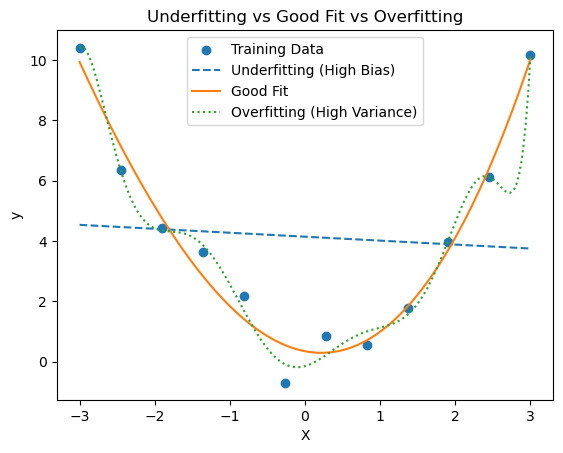

In [71]:
# Train
underfit_model.fit(X,y)
good_model.fit(X,y)
overfit_model.fit(X,y)

# Predict
y_under = underfit_model.predict(X_test)
y_good = good_model.predict(X_test)
y_over = overfit_model.predict(X_test)

# Plot
plt.scatter(X,y,label="Training Data")
plt.plot(X_test,y_under,label="Underfitting (High Bias)",linestyle="--")
plt.plot(X_test,y_good,label="Good Fit")
plt.plot(X_test,y_over,label="Overfitting (High Variance)",linestyle=":")

plt.xlabel("X")
plt.ylabel("y")
plt.title("Underfitting vs Good Fit vs Overfitting")
plt.legend()
plt.show()